---
title: "Introducing drug-nme"
subtitle: "Where I Get Information on Drug Approvals"
author: "Tony E. Lin"
date: "2026-08-05"
categories: [Data Analysis, Python, Plots, Writing]
---

# Introduction

The last two posts were on Eroom's Law and how I was able to draw that figure. I guess now is a good a time as any to introduce a Python package I wrote that pulls FDA approved drugs. I would like to introduce **drug-nme** for all your drug approval pulling needs!

## Reasons
This is something that I have worked on and off over the past year or so. Pulling information of FDA drug approvals is important for many projects, analysis, and for gauging trends of the current drug developemnt pipeline. Each year, Nature Reviews Drug Discovery releases a short write-up of the FDA drug approvals the previous year. The figures are standard. A single stacked barplot showing New Molecular Entities (NMEs) and Biologics License Applications (BLAs). This figure can be seen as Figure 1 [here](https://www.nature.com/articles/d41573-026-00001-z).

Stacked bar plots aren't a problem. The problem is pulling the information. I had bookmarked a great [blog post](https://drzinph.com/how-to-scrape-fda-drug-approval-data-with-python/#:~:text=In%20this%20tutorial%2C%20we%20will,drug%20approval%20data%20with%20Python.&text=©2026%20Phyo%20Phyo%20Kyaw%20Zin,%7C%20Theme%20by%20SuperbThemes.Com) by Dr. Phyo Phyo Zin for just this occasion. At that point I was not families with web scraping.

I had come across the blog post a couple of months to a year after it was published. Running the code, I quickly realized that there was an issue - the information pulled from the FDA regularly changes. Some sites are archived, giving it a whole new link. This broke Dr. Zin's post. It is an easy fix, but it would be annoying to constantly make these tweaks.

## Writing drug-nme

My original workaround to the issues with the FDA dataset was to use a different dataset -  The [Guide to Pharmacology](https://www.guidetopharmacology.org). This is a great resource that plugs into larger sources, like ChEMBL, but collects specific datasets regarding drug approvals. Finding this site, and using their handy API, I originally abandoned the FDA dataset in favor to GtP. With the information from GtP, I was able to make a pretty handy chart. The downsides are that it lacked information that I wanted, NME and BLA labels. But that could be forgiven as I was able to get informaiton to classify drug approvals by targets. overall, the figure looked decent.

![Bar plot vesion 1](img/21-GtP.png)

**NOTE:** At the end of August, Guide to Pharmacology will require users to access the website. Additional details can be found on their [blog here](https://blog.guidetopharmacology.org/2026/07/29/user-registration-is-coming-to-gtopdb/). Updates will to drug-nme will be forthcoming.

But I quickly realized a huge mistake with this figure. The information from GtP does not update as quickly as I thought. That was okay at the beginning of 2056, but I pulled the information again towards the end of 2025 and the information was still lacking approvals for the year. That was when I sat down and spent a time trying to figure out pulling data from the U.S. FDA.

The results look pretty decent. I will be honest, I had some trouble figuring out how to pull information from the CDER site. I found that only a couple of years are kept available as websites, while the rest are archived or converted to downloadable PDFs. It took a while to figure this out and, full transparency, I used AI to help me wtih that. I did not have exprience or know where to start to tackle the problem. It was intersting to see the solution and I have a better understanding of how to appraoch this problem in the future (with how to pull previous years that become archived). All of this lead me to being able to pull information for FDA drug approvals.

## Pulling FDA Approvals
First, we can extract the information. It comes back as a Pandas table.

In [8]:
from drug_nme import FDADataFetcher, FDAPlot
extract = FDADataFetcher()
df = extract.get_data()  # to get all data
print(f"Column X Row = {df.shape}")
df.head()

Column X Row = (1416, 7)


,Drug Name,Active Ingredient,Approval Date,Approval Year,NME/BLA,Route of Administration(1),Orphan Drug Designation
0,Simtriyo,centanafadine,07/24/2026,2026,NME,NaN,NaN
1,Lytenava,bevacizumab-vikg,07/24/2026,2026,BLA,NaN,NaN
2,Jideytro,zidesamtinib,07/22/2026,2026,NME,NaN,NaN
3,Lipfendra,enlicitide decanoate,07/15/2026,2026,NME,NaN,NaN
4,Revtorpyk,gedatolisib,07/14/2026,2026,NME,NaN,NaN


Since the information is already in a Pandas table, users can use their own custom method to generate a plot. But I've also inlcuded a few handy functions for plotting as well. Here is an example of the stacked plot to mimic the plots from the Nature Drug Reviews.

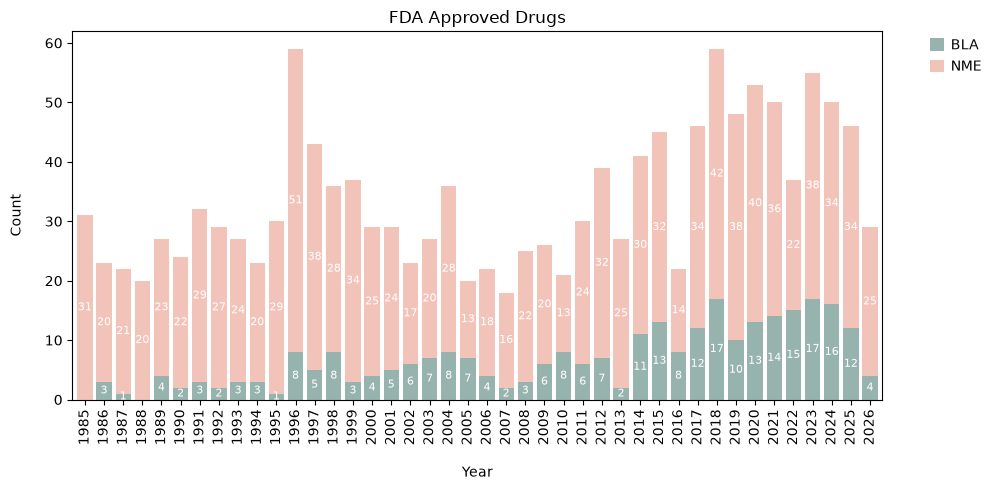

<Axes: title={'center': 'FDA Approved Drugs'}, xlabel='Year', ylabel='Count'>

In [5]:
plot = FDAPlot(df)
plot.stacked(palette=['#97B3AE','#F2C3B9'], legend_loc='out right upper')

Full tutorials can be found at the [drug-nme repository](https://github.com/tlint101/drug_nme/tree/main).